In [12]:
import pyabc
pyabc.__version__

'0.12.17'

In [13]:
# ✅ Correct imports for the API shown by inspect.signature(Parameters)

from clone_competition_simulation.parameters import Parameters
from clone_competition_simulation.parameters.times_validation import TimeParameters
from clone_competition_simulation.parameters.population_validation import PopulationParameters
from clone_competition_simulation.parameters.fitness_validation import FitnessParameters

# Now locate Gene / MutationGenerator / NormalDist in YOUR install:
import pkgutil, clone_competition_simulation as ccs

mods = sorted([m.name for m in pkgutil.walk_packages(ccs.__path__, ccs.__name__ + ".")])
# show only likely modules
[x for x in mods if any(k in x.lower() for k in ["fitness", "mutation", "dist", "gene"])]


['clone_competition_simulation.fitness',
 'clone_competition_simulation.fitness.fitness_classes',
 'clone_competition_simulation.parameters.fitness_validation',
 'clone_competition_simulation.simulation_algorithms.general_2D_class',
 'clone_competition_simulation.simulation_algorithms.general_differentiated_cell_class',
 'clone_competition_simulation.simulation_algorithms.general_sim_class']

In [14]:
import os
import shutil
import gc
import logging
import warnings
import numpy as np
import pyabc
from loguru import logger

# 1. THE SILENCERS (Prevents the "Wall of Text" crash)
warnings.filterwarnings('ignore', category=RuntimeWarning)
logging.getLogger("pyabc").setLevel(logging.ERROR)
logger.remove() 
np.seterr(divide='ignore', invalid='ignore')

{'divide': 'ignore', 'over': 'warn', 'under': 'ignore', 'invalid': 'ignore'}

In [7]:
import os
import numpy as np
import pandas as pd

from pyabc import ABCSMC, Distribution, RV
from pyabc.sampler import MulticoreEvalParallelSampler

from clone_competition_simulation.parameters import Parameters
from clone_competition_simulation.parameters.times_validation import TimeParameters
from clone_competition_simulation.parameters.population_validation import PopulationParameters
from clone_competition_simulation.parameters.fitness_validation import FitnessParameters
from clone_competition_simulation.fitness.fitness_classes import Gene, MutationGenerator, NormalDist

# ----------------------------
# CONFIG
# ----------------------------
CSV = "dnds_long_removed_outliers.csv"
GENE = "AJUBA"                 # change to NOTCH1 / TP53 etc.
OUTDIR = f"abc_{GENE}"
os.makedirs(OUTDIR, exist_ok=True)

AGE_BINS   = [(20,29),(30,39),(40,49),(50,59),(60,120)]
AGE_LABELS = np.array([25,35,45,55,70], dtype=float)

GRID_SIDE = 50
MAX_AGE = 80
DIVISION_RATE = 50

FIT_VAR = 0.02
SYN_PROP = 0.4
MIN_SIZE_DNDS = 10   # A1 stabilised

# ABC controls
POP_SIZE = 200
N_PROCS = 8
MIN_EPS = 0.15
MAX_POPS = 10

# ----------------------------
# Data -> observed summary (log10 median dN/dS per bin)
# ----------------------------
df = pd.read_csv(CSV)
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["gene_name","donor_id","Age","dnds"])
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["dnds"] = pd.to_numeric(df["dnds"], errors="coerce")
df = df.dropna(subset=["Age","dnds"])

df_gene = df[df["gene_name"] == GENE].copy()

def make_target_curve(dfg):
    d = dfg.copy()
    d = d[(d["dnds"] > 0) & np.isfinite(d["dnds"]) & np.isfinite(d["Age"])]
    y = []
    for lo, hi in AGE_BINS:
        vals = d.loc[(d["Age"]>=lo) & (d["Age"]<=hi), "dnds"].to_numpy(dtype=float)
        vals = vals[np.isfinite(vals) & (vals > 0)]
        y.append(np.nan if vals.size == 0 else np.log10(np.median(vals)))
    return np.array(y, dtype=float)

y_obs = make_target_curve(df_gene)
print("Observed:", y_obs, "finite bins:", np.isfinite(y_obs).sum())

y_obs_dict = {f"y{i}": (float(y_obs[i]) if np.isfinite(y_obs[i]) else np.nan)
              for i in range(len(AGE_LABELS))}

# ----------------------------
# Simulator -> summary stats
# ----------------------------
def sim_gene_curve(gene, seed, mu, fit_mean, ages=AGE_LABELS, min_size=MIN_SIZE_DNDS):
    np.random.seed(seed)

    mut_gen = MutationGenerator(
        genes=[
            Gene(
                name=gene,
                mutation_distribution=NormalDist(mean=float(fit_mean), var=float(FIT_VAR)),
                synonymous_proportion=float(SYN_PROP),
                weight=1
            )
        ]
    )

    p = Parameters(
        algorithm="WF2D",
        times=TimeParameters(max_time=MAX_AGE, division_rate=DIVISION_RATE),
        population=PopulationParameters(
            initial_cells=GRID_SIDE * GRID_SIDE,
            cell_in_own_neighbourhood=True
        ),
        fitness=FitnessParameters(
            mutation_rates=float(mu),
            mutation_generator=mut_gen
        )
    )

    sim = p.get_simulator()
    sim.run_sim()

    y = []
    for a in ages:
        dnds = sim.get_dnds(t=float(a), gene=gene, min_size=min_size)
        if (dnds is None) or (not np.isfinite(dnds)) or (dnds <= 0):
            y.append(np.nan)
        else:
            y.append(np.log10(dnds))
    return np.array(y, dtype=float)

def rmse_nan_safe(sim_y, obs_y, min_bins=3):
    m = np.isfinite(sim_y) & np.isfinite(obs_y)
    if m.sum() < min_bins:
        return 1e6
    return float(np.sqrt(np.mean((sim_y[m] - obs_y[m])**2)))

def model(pars):
    mu = float(pars["mu"])
    fit_mean = float(pars["fit_mean"])
    seed = np.random.randint(0, 2**31 - 1)

    y_sim = sim_gene_curve(GENE, seed=seed, mu=mu, fit_mean=fit_mean)

    return {f"y{i}": (float(y_sim[i]) if np.isfinite(y_sim[i]) else np.nan)
            for i in range(len(AGE_LABELS))}

def distance(sim, obs):
    sim_y = np.array([sim[f"y{i}"] for i in range(len(AGE_LABELS))], dtype=float)
    obs_y = np.array([obs[f"y{i}"] for i in range(len(AGE_LABELS))], dtype=float)
    return rmse_nan_safe(sim_y, obs_y, min_bins=3)

# ----------------------------
# Priors
# ----------------------------
priors = Distribution(
    mu=RV("loguniform", 1e-6, 1e-2),
    fit_mean=RV("uniform", 1.0, 0.30)
)

# ----------------------------
# Run ABC-SMC
# ----------------------------
sampler = MulticoreEvalParallelSampler(n_procs=N_PROCS)
abc = ABCSMC(model, priors, distance, population_size=POP_SIZE, sampler=sampler)

db_path = "sqlite:///" + os.path.join(OUTDIR, f"{GENE}_abc.db")
abc.new(db_path, y_obs_dict)

history = abc.run(minimum_epsilon=MIN_EPS, max_nr_populations=MAX_POPS)

print("✅ Done. DB:", db_path)

# ----------------------------
# Save posterior particles
# ----------------------------
df_post, w = history.get_distribution()
df_post["weight"] = w
post_path = os.path.join(OUTDIR, f"{GENE}_posterior.csv")
df_post.to_csv(post_path, index=False)
print("✅ Posterior saved:", post_path)

# Quick weighted quantiles
def weighted_quantile(x, w, qs):
    x = np.asarray(x); w = np.asarray(w)
    idx = np.argsort(x)
    x = x[idx]; w = w[idx]
    cdf = np.cumsum(w) / np.sum(w)
    return np.interp(qs, cdf, x)

for p in ["mu", "fit_mean"]:
    q = weighted_quantile(df_post[p].values, w, [0.1, 0.5, 0.9])
    print(p, "10/50/90:", q)

ABC.Sampler INFO: Parallelize sampling on 8 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-03-04 11:08:12>
ABC INFO: Calibration sample t = -1.


Observed: [2.88165818 2.8550826  2.73008546 3.18739026 3.02755149] finite bins: 5


ABC INFO: t: 0, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 2.0000e+02.
ABC INFO: t: 1, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 2.2672e+01.
ABC INFO: t: 2, eps: 2.47545862e+00.
ABC INFO: Accepted: 200 / 237 = 8.4388e-01, ESS: 1.3217e+02.
ABC INFO: t: 3, eps: 1.78866145e+00.
ABC INFO: Accepted: 200 / 506 = 3.9526e-01, ESS: 1.0561e+02.
ABC INFO: t: 4, eps: 1.58709244e+00.
ABC INFO: Accepted: 200 / 513 = 3.8986e-01, ESS: 1.4085e+02.
ABC INFO: t: 5, eps: 1.47700806e+00.
ABC INFO: Accepted: 200 / 763 = 2.6212e-01, ESS: 1.3223e+02.
ABC INFO: t: 6, eps: 1.39259883e+00.
ABC INFO: Accepted: 200 / 1102 = 1.8149e-01, ESS: 1.2118e+02.
ABC INFO: t: 7, eps: 1.31376664e+00.
ABC INFO: Accepted: 200 / 2117 = 9.4473e-02, ESS: 1.5050e+02.
ABC INFO: t: 8, eps: 1.26163753e+00.
ABC INFO: Accepted: 200 / 3004 = 6.6578e-02, ESS: 1.6253e+02.
ABC INFO: t: 9, eps: 1.20913872e+00.
ABC INFO: Accepted: 200 / 5454 = 3.6670e-02, ESS: 1.6470e+02.
ABC INFO: Stop: 

✅ Done. DB: sqlite:///abc_AJUBA/AJUBA_abc.db
✅ Posterior saved: abc_AJUBA/AJUBA_posterior.csv
mu 10/50/90: [0.00046322 0.00076273 0.00122433]
fit_mean 10/50/90: [1.22942163 1.26760584 1.29405988]


In [8]:
# --- 2. CONFIGURATION ---
CSV = "dnds_long_removed_outliers.csv"
GENE = "NOTCH1"                 # Changed from AJUBA
OUTDIR = f"abc_{GENE}"

# Cleanup broken database to fix AssertionError
if os.path.exists(OUTDIR):
    shutil.rmtree(OUTDIR)
os.makedirs(OUTDIR, exist_ok=True)

AGE_BINS   = [(20,29),(30,39),(40,49),(50,59),(60,120)]
AGE_LABELS = np.array([25,35,45,55,70], dtype=float)

GRID_SIDE = 50
MAX_AGE = 80 # Increased to 100 to handle the 60-120 age bin
DIVISION_RATE = 50

FIT_VAR = 0.02
SYN_PROP = 0.4
MIN_SIZE_DNDS = 10   # A1 stabilised

# ABC controls
POP_SIZE = 200
N_PROCS = 8
MIN_EPS = 0.15
MAX_POPS = 10

# ----------------------------
# Data -> observed summary (log10 median dN/dS per bin)
# ----------------------------
df = pd.read_csv(CSV)
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["gene_name","donor_id","Age","dnds"])
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["dnds"] = pd.to_numeric(df["dnds"], errors="coerce")
df = df.dropna(subset=["Age","dnds"])

df_gene = df[df["gene_name"] == GENE].copy()

def make_target_curve(dfg):
    d = dfg.copy()
    d = d[(d["dnds"] > 0) & np.isfinite(d["dnds"]) & np.isfinite(d["Age"])]
    y = []
    for lo, hi in AGE_BINS:
        vals = d.loc[(d["Age"]>=lo) & (d["Age"]<=hi), "dnds"].to_numpy(dtype=float)
        vals = vals[np.isfinite(vals) & (vals > 0)]
        y.append(np.nan if vals.size == 0 else np.log10(np.median(vals)))
    return np.array(y, dtype=float)

y_obs = make_target_curve(df_gene)
print(f"Observed {GENE}:", y_obs, "finite bins:", np.isfinite(y_obs).sum())

y_obs_dict = {f"y{i}": (float(y_obs[i]) if np.isfinite(y_obs[i]) else np.nan)
              for i in range(len(AGE_LABELS))}

# ----------------------------
# Simulator -> summary stats
# ----------------------------
def sim_gene_curve(gene, seed, mu, fit_mean, ages=AGE_LABELS, min_size=MIN_SIZE_DNDS):
    np.random.seed(seed)
    # Using your specific simulation library structure
    mut_gen = MutationGenerator(
        genes=[
            Gene(
                name=gene,
                mutation_distribution=NormalDist(mean=float(fit_mean), var=float(FIT_VAR)),
                synonymous_proportion=float(SYN_PROP),
                weight=1
            )
        ]
    )

    p = Parameters(
        algorithm="WF2D",
        times=TimeParameters(max_time=MAX_AGE, division_rate=DIVISION_RATE),
        population=PopulationParameters(
            initial_cells=GRID_SIDE * GRID_SIDE,
            cell_in_own_neighbourhood=True
        ),
        fitness=FitnessParameters(
            mutation_rates=float(mu),
            mutation_generator=mut_gen
        )
    )

    sim = p.get_simulator()
    sim.run_sim()

    y = []
    for a in ages:
        dnds = sim.get_dnds(t=float(a), gene=gene, min_size=min_size)
        if (dnds is None) or (not np.isfinite(dnds)) or (dnds <= 0):
            y.append(np.nan)
        else:
            y.append(np.log10(dnds))
    return np.array(y, dtype=float)

def rmse_nan_safe(sim_y, obs_y, min_bins=3):
    m = np.isfinite(sim_y) & np.isfinite(obs_y)
    if m.sum() < min_bins:
        return 1e6
    return float(np.sqrt(np.mean((sim_y[m] - obs_y[m])**2)))

def model(pars):
    mu = float(pars["mu"])
    fit_mean = float(pars["fit_mean"])
    seed = np.random.randint(0, 2**31 - 1)
    y_sim = sim_gene_curve(GENE, seed=seed, mu=mu, fit_mean=fit_mean)
    return {f"y{i}": (float(y_sim[i]) if np.isfinite(y_sim[i]) else np.nan)
            for i in range(len(AGE_LABELS))}

def distance(sim, obs):
    sim_y = np.array([sim[f"y{i}"] for i in range(len(AGE_LABELS))], dtype=float)
    obs_y = np.array([obs[f"y{i}"] for i in range(len(AGE_LABELS))], dtype=float)
    return rmse_nan_safe(sim_y, obs_y, min_bins=3)

# ----------------------------
# Priors (ADJUSTED FOR NOTCH1)
# ----------------------------
priors = Distribution(
    mu=RV("loguniform", 1e-7, 1e-4),   # Increased mu floor for NOTCH1
    fit_mean=RV("uniform", 1.0, 0.70)  # Increased fitness ceiling to 1.7
)

# ----------------------------
# Run ABC-SMC
# ----------------------------
sampler = MulticoreEvalParallelSampler(n_procs=N_PROCS)
abc = ABCSMC(model, priors, distance, population_size=POP_SIZE, sampler=sampler)

db_path = "sqlite:///" + os.path.join(OUTDIR, f"{GENE}_abc.db")
abc.new(db_path, y_obs_dict)

print(f"🚀 Starting ABC for {GENE}. Silencing logs to prevent crash...")
history = abc.run(minimum_epsilon=MIN_EPS, max_nr_populations=MAX_POPS)

print("✅ Done. DB:", db_path)

# ----------------------------
# Save posterior particles
# ----------------------------
df_post, w = history.get_distribution()
df_post["weight"] = w
post_path = os.path.join(OUTDIR, f"{GENE}_posterior.csv")
df_post.to_csv(post_path, index=False)
print("✅ Posterior saved:", post_path)

# Results analysis
def weighted_quantile(x, w, qs):
    x = np.asarray(x); w = np.asarray(w)
    idx = np.argsort(x)
    x = x[idx]; w = w[idx]
    cdf = np.cumsum(w) / np.sum(w)
    return np.interp(qs, cdf, x)

for p in ["mu", "fit_mean"]:
    q = weighted_quantile(df_post[p].values, w, [0.1, 0.5, 0.9])
    print(p, "10/50/90:", q)

ABC.Sampler INFO: Parallelize sampling on 8 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-03-04 13:47:14>
ABC INFO: Calibration sample t = -1.


Observed NOTCH1: [2.15186192 1.70169948        nan 1.77124284 2.15679643] finite bins: 4
🚀 Starting ABC for NOTCH1. Silencing logs to prevent crash...


ABC INFO: t: 0, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 2.0000e+02.
ABC INFO: t: 1, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 3.6857e+01.
ABC INFO: t: 2, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 9.5658e+01.
ABC INFO: t: 3, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 2.1822e+01.
ABC INFO: t: 4, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 1.1252e+02.
ABC INFO: t: 5, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 2.9875e+01.
ABC INFO: t: 6, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 4.0682e+01.
ABC INFO: t: 7, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 3.7386e+01.
ABC INFO: t: 8, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 1.7232e+01.
ABC INFO: t: 9, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 2.9244e+01.
ABC INFO: Stop: Maxi

✅ Done. DB: sqlite:///abc_NOTCH1/NOTCH1_abc.db
✅ Posterior saved: abc_NOTCH1/NOTCH1_posterior.csv
mu 10/50/90: [3.47628429e-07 4.49738402e-06 4.95582831e-05]
fit_mean 10/50/90: [1.07731794 1.2464223  1.63536568]


In [9]:
import os
import shutil
import gc
import logging
import warnings
import numpy as np
import pandas as pd
import pyabc
from pyabc import ABCSMC, RV, Distribution
from pyabc.sampler import MulticoreEvalParallelSampler
from loguru import logger
# Ensure your simulation imports (MutationGenerator, Parameters, etc.) are available

# --- 1. SILENCE LOGGING (Prevents Browser Crash) ---
warnings.filterwarnings('ignore', category=RuntimeWarning)
logging.getLogger("pyabc").setLevel(logging.ERROR)
logger.remove() 

# --- 2. CONFIGURATION ---
CSV = "dnds_long_removed_outliers.csv"
GENE = "TP53"                 # Adjusted to TP53 (Check CSV if it's 'p53' or 'TP53')
OUTDIR = f"abc_{GENE}"

# Cleanup broken database to fix AssertionError
if os.path.exists(OUTDIR):
    shutil.rmtree(OUTDIR)
os.makedirs(OUTDIR, exist_ok=True)

AGE_BINS   = [(20,29),(30,39),(40,49),(50,59),(60,120)]
AGE_LABELS = np.array([25,35,45,55,70], dtype=float)

GRID_SIDE = 50
MAX_AGE = 80 
DIVISION_RATE = 50

FIT_VAR = 0.02
SYN_PROP = 0.4
MIN_SIZE_DNDS = 10   

# ABC controls
POP_SIZE = 200
N_PROCS = 8
MIN_EPS = 0.15
MAX_POPS = 10

# ----------------------------
# Data -> observed summary
# ----------------------------
df = pd.read_csv(CSV)
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["gene_name","donor_id","Age","dnds"])
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["dnds"] = pd.to_numeric(df["dnds"], errors="coerce")
df = df.dropna(subset=["Age","dnds"])

df_gene = df[df["gene_name"] == GENE].copy()

def make_target_curve(dfg):
    d = dfg.copy()
    d = d[(d["dnds"] > 0) & np.isfinite(d["dnds"]) & np.isfinite(d["Age"])]
    y = []
    for lo, hi in AGE_BINS:
        vals = d.loc[(d["Age"]>=lo) & (d["Age"]<=hi), "dnds"].to_numpy(dtype=float)
        vals = vals[np.isfinite(vals) & (vals > 0)]
        y.append(np.nan if vals.size == 0 else np.log10(np.median(vals)))
    return np.array(y, dtype=float)

y_obs = make_target_curve(df_gene)
print(f"Observed {GENE}:", y_obs, "finite bins:", np.isfinite(y_obs).sum())

y_obs_dict = {f"y{i}": (float(y_obs[i]) if np.isfinite(y_obs[i]) else np.nan)
              for i in range(len(AGE_LABELS))}

# ----------------------------
# Simulator -> summary stats
# ----------------------------
def sim_gene_curve(gene, seed, mu, fit_mean, ages=AGE_LABELS, min_size=MIN_SIZE_DNDS):
    np.random.seed(seed)
    mut_gen = MutationGenerator(
        genes=[
            Gene(
                name=gene,
                mutation_distribution=NormalDist(mean=float(fit_mean), var=float(FIT_VAR)),
                synonymous_proportion=float(SYN_PROP),
                weight=1
            )
        ]
    )

    p = Parameters(
        algorithm="WF2D",
        times=TimeParameters(max_time=MAX_AGE, division_rate=DIVISION_RATE),
        population=PopulationParameters(
            initial_cells=GRID_SIDE * GRID_SIDE,
            cell_in_own_neighbourhood=True
        ),
        fitness=FitnessParameters(
            mutation_rates=float(mu),
            mutation_generator=mut_gen
        )
    )

    sim = p.get_simulator()
    sim.run_sim()

    y = []
    for a in ages:
        dnds = sim.get_dnds(t=float(a), gene=gene, min_size=min_size)
        if (dnds is None) or (not np.isfinite(dnds)) or (dnds <= 0):
            y.append(np.nan)
        else:
            y.append(np.log10(dnds))
    return np.array(y, dtype=float)

def rmse_nan_safe(sim_y, obs_y, min_bins=3):
    m = np.isfinite(sim_y) & np.isfinite(obs_y)
    if m.sum() < min_bins:
        return 1e6
    return float(np.sqrt(np.mean((sim_y[m] - obs_y[m])**2)))

def model(pars):
    mu = float(pars["mu"])
    fit_mean = float(pars["fit_mean"])
    seed = np.random.randint(0, 2**31 - 1)
    y_sim = sim_gene_curve(GENE, seed=seed, mu=mu, fit_mean=fit_mean)
    return {f"y{i}": (float(y_sim[i]) if np.isfinite(y_sim[i]) else np.nan)
            for i in range(len(AGE_LABELS))}

def distance(sim, obs):
    sim_y = np.array([sim[f"y{i}"] for i in range(len(AGE_LABELS))], dtype=float)
    obs_y = np.array([obs[f"y{i}"] for i in range(len(AGE_LABELS))], dtype=float)
    return rmse_nan_safe(sim_y, obs_y, min_bins=3)

# ----------------------------
# Priors (ADJUSTED FOR TP53)
# ----------------------------
priors = Distribution(
    mu=RV("loguniform", 1e-8, 1e-5),   # Adjusted for TP53 typical rates
    fit_mean=RV("uniform", 1.0, 0.60)  # Allows fitness up to 1.6
)

# ----------------------------
# Run ABC-SMC
# ----------------------------
sampler = MulticoreEvalParallelSampler(n_procs=N_PROCS)
abc = ABCSMC(model, priors, distance, population_size=POP_SIZE, sampler=sampler)

db_path = "sqlite:///" + os.path.join(OUTDIR, f"{GENE}_abc.db")
abc.new(db_path, y_obs_dict)

print(f"🚀 Starting ABC for {GENE}. Silencing logs to prevent crash...")
history = abc.run(minimum_epsilon=MIN_EPS, max_nr_populations=MAX_POPS)

print("✅ Done. DB:", db_path)

# ----------------------------
# Save posterior particles
# ----------------------------
df_post, w = history.get_distribution()
df_post["weight"] = w
post_path = os.path.join(OUTDIR, f"{GENE}_posterior.csv")
df_post.to_csv(post_path, index=False)
print("✅ Posterior saved:", post_path)

def weighted_quantile(x, w, qs):
    x = np.asarray(x); w = np.asarray(w)
    idx = np.argsort(x)
    x = x[idx]; w = w[idx]
    cdf = np.cumsum(w) / np.sum(w)
    return np.interp(qs, cdf, x)

for p in ["mu", "fit_mean"]:
    q = weighted_quantile(df_post[p].values, w, [0.1, 0.5, 0.9])
    print(p, "10/50/90:", q)

ABC.Sampler INFO: Parallelize sampling on 8 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-03-04 21:18:46>
ABC INFO: Calibration sample t = -1.


Observed TP53: [3.35506034 2.82806143 2.62186773 2.88050377 2.76927615] finite bins: 5
🚀 Starting ABC for TP53. Silencing logs to prevent crash...


ABC INFO: t: 0, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 2.0000e+02.
ABC INFO: t: 1, eps: 1.00000000e+06.
ABC.History INFO: Done <ABCSMC id=1, duration=0:01:48.077274, end_time=2026-03-04 21:20:34>


AssertionError: The population total weight nan is not normalized.

In [10]:
import os, shutil, gc, logging, warnings
import numpy as np
import pandas as pd
import pyabc
from pyabc import ABCSMC, RV, Distribution
from pyabc.sampler import MulticoreEvalParallelSampler
from loguru import logger

# --- 1. SILENCERS ---
warnings.filterwarnings('ignore', category=RuntimeWarning)
logging.getLogger("pyabc").setLevel(logging.ERROR)
logger.remove() 

# --- 2. CONFIGURATION ---
CSV = "dnds_long_removed_outliers.csv"
N_PROCS = 8
POP_SIZE = 200
MIN_EPS = 0.15
MAX_POPS = 10
MAX_AGE = 80 # To cover the 120 age bin

# Define the Martincorena Esophagus Queue
queue_settings = {
    "NOTCH2": {"mu": (1e-7, 1e-4), "fit": (1.0, 0.5)},
    "FAT1":   {"mu": (1e-7, 1e-4), "fit": (1.0, 0.4)},
    "PIK3CA": {"mu": (1e-8, 1e-5), "fit": (1.0, 0.4)},
    "KMT2D":  {"mu": (1e-7, 1e-4), "fit": (1.0, 0.3)}
}

# --- 3. LOOP ---
for GENE, params in queue_settings.items():
    print(f"\n🚀 QUEUE START: {GENE}")
    
    OUTDIR = f"abc_{GENE}"
    if os.path.exists(OUTDIR): shutil.rmtree(OUTDIR)
    os.makedirs(OUTDIR, exist_ok=True)

    # Re-run target curve for this specific gene
    df = pd.read_csv(CSV)
    df_gene = df[df["gene_name"] == GENE].copy()
    
    # ... (Insert your make_target_curve function here) ...
    y_obs = make_target_curve(df_gene)
    y_obs_dict = {f"y{i}": (float(y_obs[i]) if np.isfinite(y_obs[i]) else np.nan) 
                  for i in range(len(AGE_LABELS))}

    # Define Priors for this gene
    priors = Distribution(
        mu=RV("loguniform", *params["mu"]),
        fit_mean=RV("uniform", *params["fit"])
    )

    # Initialize and Run
    sampler = MulticoreEvalParallelSampler(n_procs=N_PROCS)
    abc = ABCSMC(model, priors, distance, population_size=POP_SIZE, sampler=sampler)
    db_path = "sqlite:///" + os.path.join(OUTDIR, f"{GENE}_abc.db")
    
    abc.new(db_path, y_obs_dict)
    history = abc.run(minimum_epsilon=MIN_EPS, max_nr_populations=MAX_POPS)

    # Save Results
    df_post, w = history.get_distribution()
    df_post["weight"] = w
    df_post.to_csv(os.path.join(OUTDIR, f"{GENE}_posterior.csv"), index=False)
    
    print(f"✅ {GENE} Done. Median Fit: {np.median(df_post['fit_mean']):.3f}")
    del abc, history
    gc.collect()

ABC.Sampler INFO: Parallelize sampling on 8 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-03-04 21:26:11>
ABC INFO: Calibration sample t = -1.



🚀 QUEUE START: NOTCH2


ABC INFO: t: 0, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 2.0000e+02.
ABC INFO: t: 1, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 8.6680e+01.
ABC INFO: t: 2, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 3.0473e+01.
ABC INFO: t: 3, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 4.1314e+01.
ABC INFO: t: 4, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 2.8923e+01.
ABC INFO: t: 5, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 2.8616e+01.
ABC INFO: t: 6, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 4.4516e+01.
ABC INFO: t: 7, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 1.4160e+01.
ABC INFO: t: 8, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 4.7796e+01.
ABC INFO: t: 9, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 9.2940e+01.
ABC INFO: Stop: Maxi

✅ NOTCH2 Done. Median Fit: 1.232

🚀 QUEUE START: FAT1


ABC INFO: t: 0, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 2.0000e+02.
ABC INFO: t: 1, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 5.8750e+01.
ABC INFO: t: 2, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 5.0723e+01.
ABC INFO: t: 3, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 2.4172e+01.
ABC INFO: t: 4, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 3.4748e+01.
ABC INFO: t: 5, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 4.6961e+01.
ABC INFO: t: 6, eps: 1.00000000e+06.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 2.0628e+01.
ABC INFO: t: 7, eps: 1.00000000e+06.
Process Process-365:
Process Process-368:
Process Process-362:
Process Process-366:
Process Process-367:
Process Process-364:
Process Process-363:
Process Process-361:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Trac

KeyboardInterrupt: 

KeyboardInterrupt
KeyboardInterrupt
KeyboardInterrupt
KeyboardInterrupt
Traceback (most recent call last):
  File "/home/zechen/miniconda3/envs/spatial_sim/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/zechen/miniconda3/envs/spatial_sim/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/zechen/miniconda3/envs/spatial_sim/lib/python3.11/site-packages/pyabc/sampler/multicore_evaluation_parallel.py", line 42, in work
    new_sim = simulate_one()
              ^^^^^^^^^^^^^^
  File "/home/zechen/miniconda3/envs/spatial_sim/lib/python3.11/site-packages/pyabc/inference_util/inference_util.py", line 446, in simulate_one
    particle = evaluate_proposal(
               ^^^^^^^^^^^^^^^^^^
  File "/home/zechen/miniconda3/envs/spatial_sim/lib/python3.11/site-packages/pyabc/inference_util/inference_util.py", line 239, in evaluate_proposal
    model_result = models[m_ss].accept(


In [ ]:
import os
import shutil
import gc
import logging
import warnings
import numpy as np
import pandas as pd
import pyabc
from pyabc import ABCSMC, RV, Distribution, LocalTransition
from pyabc.sampler import MulticoreEvalParallelSampler

# --- 1. SETTINGS & SILENCERS ---
warnings.filterwarnings('ignore')
logging.getLogger("pyabc").setLevel(logging.ERROR)

GENE = "TP53"
CSV = "dnds_long_removed_outliers.csv"
OUTDIR = f"abc_{GENE}"

# Age bins matching your data structure
AGE_BINS   = [(20,29),(30,39),(40,49),(50,59),(60,120)]
AGE_LABELS = np.array([25,35,45,55,70], dtype=float)

# --- 2. CLEANUP ---
if os.path.exists(OUTDIR):
    shutil.rmtree(OUTDIR)
os.makedirs(OUTDIR, exist_ok=True)

# --- 3. TARGET DATA PREPARATION ---
df = pd.read_csv(CSV)
df_gene = df[df["gene_name"] == GENE].copy()

def make_target_curve(dfg):
    y = []
    for lo, hi in AGE_BINS:
        vals = dfg.loc[(dfg["Age"]>=lo) & (dfg["Age"]<=hi), "dnds"].to_numpy()
        vals = vals[np.isfinite(vals) & (vals > 0)]
        # Use log10 because dNdS values are in the hundreds/thousands
        y.append(np.log10(np.median(vals)) if vals.size > 0 else np.nan)
    return np.array(y)

y_obs = make_target_curve(df_gene)
y_obs_dict = {f"y{i}": y_obs[i] for i in range(len(AGE_LABELS))}

# --- 4. BIOLOGICAL PRIORS FOR TP53 ---
# mu: High esophagus mutation rate
# fit_mean: 1.0 (neutral) to 2.0 (100% advantage)
priors = Distribution(
    mu=RV("loguniform", 1e-8, 1e-5),
    fit_mean=RV("uniform", 1.0, 1.0) 
)

# --- 5. ROBUST DISTANCE FUNCTION ---
def distance(sim, obs):
    sim_y = np.array([sim[f"y{i}"] for i in range(len(AGE_LABELS))])
    obs_y = np.array([obs[f"y{i}"] for i in range(len(AGE_LABELS))])
    mask = np.isfinite(sim_y) & np.isfinite(obs_y)
    if mask.sum() < 2: 
        return 2.0 # Moderate penalty to keep the sampler moving
    return float(np.sqrt(np.mean((sim_y[mask] - obs_y[mask])**2)))

# --- 6. EXECUTION ---
# Using LocalTransition to prevent the 'NaN weight' error
abc = ABCSMC(
    model, 
    priors, 
    distance, 
    population_size=200, 
    sampler=MulticoreEvalParallelSampler(n_procs=8),
    transitions=LocalTransition() 
)

db_path = "sqlite:///" + os.path.join(OUTDIR, f"{GENE}_abc.db")
abc.new(db_path, y_obs_dict)

print(f"🚀 Starting stable ABC run for {GENE}...")
history = abc.run(minimum_epsilon=0.1, max_nr_populations=10)

# --- 7. SAVE OUTPUT ---
df_post, w = history.get_distribution()
df_post["weight"] = w
df_post.to_csv(os.path.join(OUTDIR, f"{GENE}_posterior.csv"), index=False)

print(f"✅ TP53 Analysis Complete. Results saved to {OUTDIR}")

In [17]:
import os
import shutil
import gc
import logging
import warnings
import numpy as np
import pandas as pd
import pyabc
from pyabc import ABCSMC, RV, Distribution, LocalTransition
from pyabc.sampler import MulticoreEvalParallelSampler
from pyabc.epsilon import QuantileEpsilon

# --- 1. SETTINGS & SILENCERS ---
warnings.filterwarnings('ignore')
logging.getLogger("pyabc").setLevel(logging.ERROR)

GENE = "NOTCH1"
CSV = "dnds_long_removed_outliers.csv"
OUTDIR = f"abc_{GENE}"
AGE_BINS = [(20,29),(30,39),(40,49),(50,59),(60,120)]
AGE_LABELS = np.array([25,35,45,55,70], dtype=float)

if os.path.exists(OUTDIR): shutil.rmtree(OUTDIR)
os.makedirs(OUTDIR, exist_ok=True)

# --- 2. TARGET DATA ---
df = pd.read_csv(CSV)
df_gene = df[df["gene_name"] == GENE].copy()

def make_target_curve(dfg):
    y = []
    for lo, hi in AGE_BINS:
        vals = dfg.loc[(dfg["Age"]>=lo) & (dfg["Age"]<=hi), "dnds"].to_numpy()
        vals = vals[np.isfinite(vals) & (vals > 0)]
        y.append(np.log10(np.median(vals)) if vals.size > 0 else np.nan)
    return np.array(y)

y_obs = make_target_curve(df_gene)
y_obs_dict = {f"y{i}": y_obs[i] for i in range(len(AGE_LABELS))}

# --- 3. ROBUST DISTANCE ---
def distance(sim, obs):
    sim_y = np.array([sim[f"y{i}"] for i in range(len(AGE_LABELS))])
    obs_y = np.array([obs[f"y{i}"] for i in range(len(AGE_LABELS))])
    
    # Only compare bins where both have data (ignores the NaN in 40-49)
    mask = np.isfinite(sim_y) & np.isfinite(obs_y)
    
    if mask.sum() < 2: 
        return 5.0 # Penalty for no overlap
        
    return np.sqrt(np.nanmean((sim_y[mask] - obs_y[mask])**2))

# --- 4. ABC SETUP ---
priors = Distribution(
    mu=RV("loguniform", 1e-7, 1e-4),
    fit_mean=RV("uniform", 1.0, 0.8) # Selection s up to 0.8
)

# Fix: In recent pyabc versions, the argument is 'eps', not 'epsilon'
# and we use 'alpha' for the quantile.
effective_eps = QuantileEpsilon(alpha=0.5, initial_epsilon=5.0)

abc = ABCSMC(
    model, 
    priors, 
    distance, 
    population_size=200, 
    sampler=MulticoreEvalParallelSampler(n_procs=8),
    eps=effective_eps, # <--- Corrected argument name
    transitions=LocalTransition() 
)

db_path = "sqlite:///" + os.path.join(OUTDIR, f"{GENE}_abc.db")
abc.new(db_path, y_obs_dict)

print(f"🚀 Starting ABC for {GENE}...")
history = abc.run(minimum_epsilon=0.05, max_nr_populations=10)

# --- 5. SAVE ---
df_post, w = history.get_distribution()
df_post["weight"] = w
df_post.to_csv(os.path.join(OUTDIR, f"{GENE}_posterior.csv"), index=False)
print(f"✅ DONE. Median s: {df_post['fit_mean'].median()-1:.3f}")

ABC.Sampler INFO: Parallelize sampling on 8 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-03-04 21:42:18>
ABC INFO: t: 0, eps: 5.00000000e+00.


🚀 Starting ABC for NOTCH1...


ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 2.0000e+02.
ABC INFO: t: 1, eps: 5.00000000e+00.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 4.3616e+01.
ABC INFO: t: 2, eps: 5.00000000e+00.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 4.5615e+01.
ABC INFO: t: 3, eps: 5.00000000e+00.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 4.2300e+01.
ABC INFO: t: 4, eps: 5.00000000e+00.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 7.9562e+01.
ABC INFO: t: 5, eps: 5.00000000e+00.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 1.4318e+01.
ABC INFO: t: 6, eps: 5.00000000e+00.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 2.2254e+01.
ABC INFO: t: 7, eps: 5.00000000e+00.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 3.6355e+01.
ABC INFO: t: 8, eps: 5.00000000e+00.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 3.6390e+01.
ABC INFO: t: 9, eps: 5.00000000e+00.
ABC INFO: Accepted: 200 / 207 = 9.6618e-01, ESS: 3.8146e+01.
ABC INFO: Stop: Maximum number of generations.
ABC.Histor

✅ DONE. Median s: 0.389


In [18]:
import os
import shutil
import logging
import warnings
import numpy as np
import pandas as pd
import pyabc
from pyabc import ABCSMC, RV, Distribution, LocalTransition
from pyabc.sampler import MulticoreEvalParallelSampler
from pyabc.epsilon import QuantileEpsilon

# --- 1. SETTINGS & SILENCERS ---
warnings.filterwarnings('ignore')
logging.getLogger("pyabc").setLevel(logging.ERROR)

GENE = "FAT1"
CSV_FILE = "dnds_long_removed_outliers.csv"
OUTDIR = f"abc_{GENE}"

# Age bins matching your data
AGE_BINS   = [(20,29),(30,39),(40,49),(50,59),(60,120)]
AGE_LABELS = np.array([25,35,45,55,70], dtype=float)

if os.path.exists(OUTDIR):
    shutil.rmtree(OUTDIR)
os.makedirs(OUTDIR, exist_ok=True)

# --- 2. DATA PREPARATION ---
df_all = pd.read_csv(CSV_FILE)
df_gene = df_all[df_all["gene_name"] == GENE].copy()

def make_target_curve(dfg):
    y = []
    for lo, hi in AGE_BINS:
        vals = dfg.loc[(dfg["Age"]>=lo) & (dfg["Age"]<=hi), "dnds"].to_numpy()
        vals = vals[np.isfinite(vals) & (vals > 0)]
        y.append(np.log10(np.median(vals)) if vals.size > 0 else np.nan)
    return np.array(y)

y_obs = make_target_curve(df_gene)
y_obs_dict = {f"y{i}": y_obs[i] for i in range(len(AGE_LABELS))}

print(f"Targeting {GENE} with Observed log10 dN/dS: {y_obs}")

# --- 3. BIOLOGICALLY INFORMED PRIORS FOR FAT1 ---
# FAT1 is massive, so we allow for a higher mutation rate (mu).
# Selection (s) is usually moderate for FAT1.
priors = Distribution(
    mu=RV("loguniform", 1e-7, 1e-3), # Higher upper bound for gene size
    fit_mean=RV("uniform", 1.0, 0.6)  # fit_mean 1.0 to 1.6 (s up to 60%)
)

# --- 4. ROBUST DISTANCE FUNCTION ---
def distance(sim, obs):
    sim_y = np.array([sim[f"y{i}"] for i in range(len(AGE_LABELS))])
    obs_y = np.array([obs[f"y{i}"] for i in range(len(AGE_LABELS))])
    mask = np.isfinite(obs_y)
    
    if not np.any(np.isfinite(sim_y[mask])):
        return 20.0 # Penalty for simulations with no growth
        
    return np.sqrt(np.nanmean((sim_y[mask] - obs_y[mask])**2))

# --- 5. ABC SETUP ---
# Standardized sampler and epsilon decay to ensure comparability
abc = ABCSMC(
    model, 
    priors, 
    distance, 
    population_size=200, 
    sampler=MulticoreEvalParallelSampler(n_procs=8),
    eps=QuantileEpsilon(alpha=0.5, initial_epsilon=15.0),
    transitions=LocalTransition() 
)

db_path = "sqlite:///" + os.path.join(OUTDIR, f"{GENE}_abc.db")
abc.new(db_path, y_obs_dict)

# --- 6. RUN ---
print(f"🚀 Starting ABC for {GENE}...")
history = abc.run(minimum_epsilon=0.05, max_nr_populations=10)

# --- 7. SAVE & SUMMARY ---
df_post, w = history.get_distribution()
df_post["weight"] = w
df_post.to_csv(os.path.join(OUTDIR, f"{GENE}_posterior.csv"), index=False)

median_s = df_post['fit_mean'].median() - 1
print(f"\n✅ {GENE} Analysis Complete.")
print(f"Median s estimate: {median_s:.3f}")

ABC.Sampler INFO: Parallelize sampling on 8 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-03-04 21:59:22>
ABC INFO: t: 0, eps: 1.50000000e+01.


Targeting FAT1 with Observed log10 dN/dS: [2.06215834 1.46599534 1.85740374 1.30592957 1.88976978]
🚀 Starting ABC for FAT1...


ABC INFO: Accepted: 200 / 544 = 3.6765e-01, ESS: 2.0000e+02.
ABC INFO: t: 1, eps: 5.45705625e-01.
ABC INFO: Accepted: 200 / 345 = 5.7971e-01, ESS: 1.2301e+02.
ABC INFO: t: 2, eps: 3.36821084e-01.
ABC INFO: Accepted: 200 / 693 = 2.8860e-01, ESS: 7.3643e+01.
ABC INFO: t: 3, eps: 2.31728133e-01.
ABC INFO: Accepted: 200 / 1486 = 1.3459e-01, ESS: 1.0162e+02.
ABC INFO: t: 4, eps: 1.56038609e-01.
ABC INFO: Accepted: 200 / 2286 = 8.7489e-02, ESS: 7.7297e+01.
ABC INFO: t: 5, eps: 8.81374353e-02.
ABC INFO: Accepted: 200 / 4430 = 4.5147e-02, ESS: 8.9894e+01.
ABC INFO: t: 6, eps: 4.46717415e-02.
ABC INFO: Accepted: 200 / 9497 = 2.1059e-02, ESS: 9.4140e+01.
ABC INFO: Stop: Minimum epsilon.
ABC.History INFO: Done <ABCSMC id=1, duration=1:39:58.294621, end_time=2026-03-04 23:39:20>



✅ FAT1 Analysis Complete.
Median s estimate: 0.446


In [21]:
import os, shutil, logging, warnings
import numpy as np
import pandas as pd
import pyabc
from pyabc import ABCSMC, RV, Distribution, LocalTransition
from pyabc.sampler import MulticoreEvalParallelSampler
from pyabc.epsilon import QuantileEpsilon

# --- 1. SETTINGS (Synchronized with AJUBA) ---
warnings.filterwarnings('ignore')
logging.getLogger("pyabc").setLevel(logging.ERROR)

GENE = "TP53"
CSV_FILE = "dnds_long_removed_outliers.csv"
OUTDIR = f"abc_{GENE}"
MAX_AGE = 80 # MUST match AJUBA for fair comparison
POP_SIZE = 200 # MUST match AJUBA

AGE_BINS   = [(20,29),(30,39),(40,49),(50,59),(60,120)]
AGE_LABELS = np.array([25,35,45,55,70], dtype=float)

if os.path.exists(OUTDIR): shutil.rmtree(OUTDIR)
os.makedirs(OUTDIR, exist_ok=True)

# --- 2. DATA PREP ---
df_all = pd.read_csv(CSV_FILE)
df_gene = df_all[df_all["gene_name"] == GENE].copy()

def make_target_curve(dfg):
    y = []
    for lo, hi in AGE_BINS:
        vals = dfg.loc[(dfg["Age"]>=lo) & (dfg["Age"]<=hi), "dnds"].to_numpy()
        vals = vals[np.isfinite(vals) & (vals > 0)]
        y.append(np.log10(np.median(vals)) if vals.size > 0 else np.nan)
    return np.array(y)

y_obs = make_target_curve(df_gene)
y_obs_dict = {f"y{i}": y_obs[i] for i in range(len(AGE_LABELS))}

# --- 3. PRIORS (Gene-Specific but Fair) ---
# We keep the LOG-UNIFORM mu and UNIFORM fit_mean logic
# but allow a higher upper bound for TP53 fitness.
priors = Distribution(
    mu=RV("loguniform", 1e-8, 1e-4), 
    fit_mean=RV("uniform", 1.0, 1.5) # s from 0.0 to 1.5 (150% advantage)
)

# --- 4. DISTANCE (Synchronized) ---
def distance(sim, obs):
    sim_y = np.array([sim[f"y{i}"] for i in range(len(AGE_LABELS))])
    obs_y = np.array([obs[f"y{i}"] for i in range(len(AGE_LABELS))])
    mask = np.isfinite(obs_y)
    if not np.any(np.isfinite(sim_y[mask])): return 20.0 
    return np.sqrt(np.nanmean((sim_y[mask] - obs_y[mask])**2))

# --- 5. ABC SETUP ---
# Ensure your model wrapper passes max_age=80!
abc = ABCSMC(
    model, 
    priors, 
    distance, 
    population_size=POP_SIZE, 
    sampler=MulticoreEvalParallelSampler(n_procs=8),
    eps=QuantileEpsilon(alpha=0.5, initial_epsilon=15.0),
    transitions=LocalTransition() 
)

db_path = "sqlite:///" + os.path.join(OUTDIR, f"{GENE}_abc.db")
abc.new(db_path, y_obs_dict)

# --- 6. RUN ---
print(f"🚀 Starting Synchronized TP53 run (Age: {MAX_AGE})...")
history = abc.run(minimum_epsilon=0.05, max_nr_populations=10)

# --- 7. SAVE ---
df_post, w = history.get_distribution()
df_post["weight"] = w
df_post.to_csv(os.path.join(OUTDIR, f"{GENE}_posterior.csv"), index=False)
print(f"✅ {GENE} Complete. Median s: {df_post['fit_mean'].median()-1:.3f}")

ABC.Sampler INFO: Parallelize sampling on 8 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-03-05 01:50:48>
ABC INFO: t: 0, eps: 1.50000000e+01.


🚀 Starting Synchronized TP53 run (Age: 80)...


ABC INFO: Accepted: 200 / 1882 = 1.0627e-01, ESS: 2.0000e+02.
ABC INFO: t: 1, eps: 1.68297451e+00.
ABC INFO: Accepted: 200 / 824 = 2.4272e-01, ESS: 1.3832e+02.
ABC INFO: t: 2, eps: 1.38463307e+00.
ABC INFO: Accepted: 200 / 1225 = 1.6327e-01, ESS: 1.5648e+02.
ABC INFO: t: 3, eps: 1.19654105e+00.
ABC INFO: Accepted: 200 / 1705 = 1.1730e-01, ESS: 1.5630e+02.
ABC INFO: t: 4, eps: 1.09410906e+00.
ABC INFO: Accepted: 200 / 2800 = 7.1429e-02, ESS: 1.7989e+02.
ABC INFO: t: 5, eps: 1.02628932e+00.
ABC INFO: Accepted: 200 / 3132 = 6.3857e-02, ESS: 1.6039e+02.
ABC INFO: t: 6, eps: 9.78415056e-01.
ABC INFO: Accepted: 200 / 3690 = 5.4201e-02, ESS: 1.8238e+02.
ABC INFO: t: 7, eps: 9.44428174e-01.
ABC INFO: Accepted: 200 / 4326 = 4.6232e-02, ESS: 1.8594e+02.
ABC INFO: t: 8, eps: 9.20061547e-01.
ABC INFO: Accepted: 200 / 4862 = 4.1135e-02, ESS: 1.5535e+02.
ABC INFO: t: 9, eps: 9.07940915e-01.
ABC INFO: Accepted: 200 / 5647 = 3.5417e-02, ESS: 1.5660e+02.
ABC INFO: Stop: Maximum number of generations.
A

✅ TP53 Complete. Median s: 1.400


In [22]:
import os, shutil, logging, warnings
import numpy as np
import pandas as pd
import pyabc
from pyabc import ABCSMC, RV, Distribution, LocalTransition
from pyabc.sampler import MulticoreEvalParallelSampler
from pyabc.epsilon import QuantileEpsilon

# --- 1. SETTINGS (Synchronized with AJUBA/TP53) ---
warnings.filterwarnings('ignore')
logging.getLogger("pyabc").setLevel(logging.ERROR)

GENE = "NOTCH2"
CSV_FILE = "dnds_long_removed_outliers.csv"
OUTDIR = f"abc_{GENE}"
MAX_AGE = 80 # MUST match AJUBA/TP53
POP_SIZE = 200 

AGE_BINS   = [(20,29),(30,39),(40,49),(50,59),(60,120)]
AGE_LABELS = np.array([25,35,45,55,70], dtype=float)

if os.path.exists(OUTDIR): shutil.rmtree(OUTDIR)
os.makedirs(OUTDIR, exist_ok=True)

# --- 2. DATA PREP ---
df_all = pd.read_csv(CSV_FILE)
df_gene = df_all[df_all["gene_name"] == GENE].copy()

def make_target_curve(dfg):
    y = []
    for lo, hi in AGE_BINS:
        vals = dfg.loc[(dfg["Age"]>=lo) & (dfg["Age"]<=hi), "dnds"].to_numpy()
        vals = vals[np.isfinite(vals) & (vals > 0)]
        y.append(np.log10(np.median(vals)) if vals.size > 0 else np.nan)
    return np.array(y)

y_obs = make_target_curve(df_gene)
y_obs_dict = {f"y{i}": y_obs[i] for i in range(len(AGE_LABELS))}

# --- 3. PRIORS (Synchronized logic) ---
# Broad mu for large gene size, s range consistent with drivers
priors = Distribution(
    mu=RV("loguniform", 1e-8, 1e-4), 
    fit_mean=RV("uniform", 1.0, 1.0) # s from 0.0 to 1.0 (100% advantage)
)

# --- 4. DISTANCE (Synchronized log10 RMSE) ---
def distance(sim, obs):
    sim_y = np.array([sim[f"y{i}"] for i in range(len(AGE_LABELS))])
    obs_y = np.array([obs[f"y{i}"] for i in range(len(AGE_LABELS))])
    mask = np.isfinite(obs_y)
    if not np.any(np.isfinite(sim_y[mask])): return 20.0 
    return np.sqrt(np.nanmean((sim_y[mask] - obs_y[mask])**2))

# --- 5. ABC SETUP ---
abc = ABCSMC(
    model, # Ensure internal model wrapper uses MAX_AGE = 80
    priors, 
    distance, 
    population_size=POP_SIZE, 
    sampler=MulticoreEvalParallelSampler(n_procs=8),
    eps=QuantileEpsilon(alpha=0.5, initial_epsilon=15.0),
    transitions=LocalTransition() 
)

db_path = "sqlite:///" + os.path.join(OUTDIR, f"{GENE}_abc.db")
abc.new(db_path, y_obs_dict)

# --- 6. RUN ---
print(f"🚀 Starting Synchronized NOTCH2 run (Age: {MAX_AGE})...")
history = abc.run(minimum_epsilon=0.05, max_nr_populations=10)

# --- 7. SAVE ---
df_post, w = history.get_distribution()
df_post["weight"] = w
df_post.to_csv(os.path.join(OUTDIR, f"{GENE}_posterior.csv"), index=False)
print(f"✅ {GENE} Complete. Median s: {df_post['fit_mean'].median()-1:.3f}")

ABC.Sampler INFO: Parallelize sampling on 8 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-03-05 03:37:57>
ABC INFO: t: 0, eps: 1.50000000e+01.


🚀 Starting Synchronized NOTCH2 run (Age: 80)...


ABC INFO: Accepted: 200 / 1679 = 1.1912e-01, ESS: 2.0000e+02.
ABC INFO: t: 1, eps: 1.02702695e+00.
ABC INFO: Accepted: 200 / 809 = 2.4722e-01, ESS: 1.5482e+02.
ABC INFO: t: 2, eps: 7.29443039e-01.
ABC INFO: Accepted: 200 / 994 = 2.0121e-01, ESS: 1.7245e+02.
ABC INFO: t: 3, eps: 5.89130302e-01.
ABC INFO: Accepted: 200 / 1625 = 1.2308e-01, ESS: 1.3840e+02.
ABC INFO: t: 4, eps: 4.90807572e-01.
ABC INFO: Accepted: 200 / 2553 = 7.8339e-02, ESS: 1.5627e+02.
ABC INFO: t: 5, eps: 4.11398118e-01.
ABC INFO: Accepted: 200 / 5123 = 3.9040e-02, ESS: 1.5793e+02.
ABC INFO: t: 6, eps: 3.63973468e-01.
ABC INFO: Accepted: 200 / 6271 = 3.1893e-02, ESS: 1.8485e+02.
ABC INFO: t: 7, eps: 3.21221488e-01.
ABC INFO: Accepted: 200 / 7357 = 2.7185e-02, ESS: 1.8655e+02.
ABC INFO: t: 8, eps: 2.82303422e-01.
ABC INFO: Accepted: 200 / 8733 = 2.2902e-02, ESS: 1.6627e+02.
ABC INFO: t: 9, eps: 2.58169742e-01.
ABC INFO: Accepted: 200 / 9744 = 2.0525e-02, ESS: 1.4419e+02.
ABC INFO: Stop: Maximum number of generations.
AB

✅ NOTCH2 Complete. Median s: 0.903


In [23]:
import os, shutil, logging, warnings
import numpy as np
import pandas as pd
import pyabc
from pyabc import ABCSMC, RV, Distribution, LocalTransition
from pyabc.sampler import MulticoreEvalParallelSampler
from pyabc.epsilon import QuantileEpsilon

# --- 1. SETTINGS (Synchronized with AJUBA/TP53/NOTCH2) ---
warnings.filterwarnings('ignore')
logging.getLogger("pyabc").setLevel(logging.ERROR)

GENE = "KMT2D"
CSV_FILE = "dnds_long_removed_outliers.csv"
OUTDIR = f"abc_{GENE}"
MAX_AGE = 80  # MUST match your previous runs
POP_SIZE = 200 

AGE_BINS   = [(20,29),(30,39),(40,49),(50,59),(60,120)]
AGE_LABELS = np.array([25,35,45,55,70], dtype=float)

if os.path.exists(OUTDIR): shutil.rmtree(OUTDIR)
os.makedirs(OUTDIR, exist_ok=True)

# --- 2. DATA PREP ---
df_all = pd.read_csv(CSV_FILE)
df_gene = df_all[df_all["gene_name"] == GENE].copy()

def make_target_curve(dfg):
    y = []
    for lo, hi in AGE_BINS:
        vals = dfg.loc[(dfg["Age"]>=lo) & (dfg["Age"]<=hi), "dnds"].to_numpy()
        vals = vals[np.isfinite(vals) & (vals > 0)]
        y.append(np.log10(np.median(vals)) if vals.size > 0 else np.nan)
    return np.array(y)

y_obs = make_target_curve(df_gene)
y_obs_dict = {f"y{i}": y_obs[i] for i in range(len(AGE_LABELS))}

# --- 3. PRIORS (Synchronized logic) ---
# Large mutational target (high mu range), s range for moderate selection
priors = Distribution(
    mu=RV("loguniform", 1e-8, 1e-4), 
    fit_mean=RV("uniform", 1.0, 1.0) # s from 0.0 to 1.0 (100% advantage)
)

# --- 4. DISTANCE (Synchronized log10 RMSE) ---
def distance(sim, obs):
    sim_y = np.array([sim[f"y{i}"] for i in range(len(AGE_LABELS))])
    obs_y = np.array([obs[f"y{i}"] for i in range(len(AGE_LABELS))])
    mask = np.isfinite(obs_y)
    if not np.any(np.isfinite(sim_y[mask])): return 20.0 
    return np.sqrt(np.nanmean((sim_y[mask] - obs_y[mask])**2))

# --- 5. ABC SETUP ---
abc = ABCSMC(
    model, # Ensure internal model wrapper uses MAX_AGE = 80
    priors, 
    distance, 
    population_size=POP_SIZE, 
    sampler=MulticoreEvalParallelSampler(n_procs=8),
    eps=QuantileEpsilon(alpha=0.5, initial_epsilon=15.0),
    transitions=LocalTransition() 
)

db_path = "sqlite:///" + os.path.join(OUTDIR, f"{GENE}_abc.db")
abc.new(db_path, y_obs_dict)

# --- 6. RUN ---
print(f"🚀 Starting Synchronized KMT2D run (Age: {MAX_AGE})...")
history = abc.run(minimum_epsilon=0.05, max_nr_populations=10)

# --- 7. SAVE ---
df_post, w = history.get_distribution()
df_post["weight"] = w
df_post.to_csv(os.path.join(OUTDIR, f"{GENE}_posterior.csv"), index=False)
print(f"✅ {GENE} Complete. Median s: {df_post['fit_mean'].median()-1:.3f}")

ABC.Sampler INFO: Parallelize sampling on 8 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-03-05 06:13:07>
ABC INFO: t: 0, eps: 1.50000000e+01.


🚀 Starting Synchronized KMT2D run (Age: 80)...


ABC INFO: Accepted: 200 / 1642 = 1.2180e-01, ESS: 2.0000e+02.
ABC INFO: t: 1, eps: 7.41137738e-01.
ABC INFO: Accepted: 200 / 794 = 2.5189e-01, ESS: 1.3383e+02.
ABC INFO: t: 2, eps: 4.73001944e-01.
ABC INFO: Accepted: 200 / 1032 = 1.9380e-01, ESS: 1.3592e+02.
ABC INFO: t: 3, eps: 3.09094860e-01.
ABC INFO: Accepted: 200 / 1562 = 1.2804e-01, ESS: 1.2803e+02.
ABC INFO: t: 4, eps: 2.08633290e-01.
ABC INFO: Accepted: 200 / 2784 = 7.1839e-02, ESS: 9.8724e+01.
ABC INFO: t: 5, eps: 1.07885950e-01.
ABC INFO: Accepted: 200 / 7427 = 2.6929e-02, ESS: 1.7814e+01.
ABC INFO: t: 6, eps: 7.39930040e-02.
ABC INFO: Accepted: 200 / 7959 = 2.5129e-02, ESS: 1.8914e+02.
ABC INFO: t: 7, eps: 4.07265675e-02.
ABC INFO: Accepted: 200 / 9614 = 2.0803e-02, ESS: 1.7745e+02.
ABC INFO: Stop: Minimum epsilon.
ABC.History INFO: Done <ABCSMC id=1, duration=1:45:03.095841, end_time=2026-03-05 07:58:10>


✅ KMT2D Complete. Median s: 0.529


In [24]:
import os, shutil, logging, warnings
import numpy as np
import pandas as pd
import pyabc
from pyabc import ABCSMC, RV, Distribution, LocalTransition
from pyabc.sampler import MulticoreEvalParallelSampler
from pyabc.epsilon import QuantileEpsilon

# --- 1. SETTINGS (Synchronized with AJUBA/TP53/KMT2D) ---
warnings.filterwarnings('ignore')
logging.getLogger("pyabc").setLevel(logging.ERROR)

GENE = "CUL3"
CSV_FILE = "dnds_long_removed_outliers.csv"
OUTDIR = f"abc_{GENE}"
MAX_AGE = 80  
POP_SIZE = 200 

AGE_BINS   = [(20,29),(30,39),(40,49),(50,59),(60,120)]
AGE_LABELS = np.array([25,35,45,55,70], dtype=float)

if os.path.exists(OUTDIR): shutil.rmtree(OUTDIR)
os.makedirs(OUTDIR, exist_ok=True)

# --- 2. DATA PREP ---
df_all = pd.read_csv(CSV_FILE)
df_gene = df_all[df_all["gene_name"] == GENE].copy()

def make_target_curve(dfg):
    y = []
    for lo, hi in AGE_BINS:
        vals = dfg.loc[(dfg["Age"]>=lo) & (dfg["Age"]<=hi), "dnds"].to_numpy()
        vals = vals[np.isfinite(vals) & (vals > 0)]
        y.append(np.log10(np.median(vals)) if vals.size > 0 else np.nan)
    return np.array(y)

y_obs = make_target_curve(df_gene)
y_obs_dict = {f"y{i}": y_obs[i] for i in range(len(AGE_LABELS))}

# --- 3. BIOLOGICALLY ADJUSTED PRIORS FOR CUL3 ---
# Medium mutational target (standard mu range).
# Selection for CUL3 is usually in the 10-40% range.
priors = Distribution(
    mu=RV("loguniform", 1e-8, 5e-5), 
    fit_mean=RV("uniform", 1.0, 0.6) # s from 0.0 to 0.6 (60% advantage)
)

# --- 4. DISTANCE (Synchronized log10 RMSE) ---
def distance(sim, obs):
    sim_y = np.array([sim[f"y{i}"] for i in range(len(AGE_LABELS))])
    obs_y = np.array([obs[f"y{i}"] for i in range(len(AGE_LABELS))])
    mask = np.isfinite(obs_y)
    if not np.any(np.isfinite(sim_y[mask])): return 20.0 
    return np.sqrt(np.nanmean((sim_y[mask] - obs_y[mask])**2))

# --- 5. ABC SETUP ---
abc = ABCSMC(
    model, 
    priors, 
    distance, 
    population_size=POP_SIZE, 
    sampler=MulticoreEvalParallelSampler(n_procs=8),
    eps=QuantileEpsilon(alpha=0.5, initial_epsilon=15.0),
    transitions=LocalTransition() 
)

db_path = "sqlite:///" + os.path.join(OUTDIR, f"{GENE}_abc.db")
abc.new(db_path, y_obs_dict)

# --- 6. RUN ---
print(f"🚀 Starting Synchronized CUL3 run (Age: {MAX_AGE})...")
history = abc.run(minimum_epsilon=0.05, max_nr_populations=10)

# --- 7. SAVE ---
df_post, w = history.get_distribution()
df_post["weight"] = w
df_post.to_csv(os.path.join(OUTDIR, f"{GENE}_posterior.csv"), index=False)
print(f"✅ {GENE} Complete. Median s: {df_post['fit_mean'].median()-1:.3f}")

ABC.Sampler INFO: Parallelize sampling on 8 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-03-05 07:58:10>
ABC INFO: t: 0, eps: 1.50000000e+01.


🚀 Starting Synchronized CUL3 run (Age: 80)...


ABC INFO: Accepted: 200 / 2793 = 7.1608e-02, ESS: 2.0000e+02.
ABC INFO: t: 1, eps: 1.81771051e+00.
ABC INFO: Accepted: 200 / 1044 = 1.9157e-01, ESS: 1.3270e+02.
ABC INFO: t: 2, eps: 1.45155402e+00.
ABC INFO: Accepted: 200 / 1354 = 1.4771e-01, ESS: 1.6066e+02.
ABC INFO: t: 3, eps: 1.25596180e+00.
ABC INFO: Accepted: 200 / 2006 = 9.9701e-02, ESS: 1.6905e+02.
ABC INFO: t: 4, eps: 1.12468288e+00.
ABC INFO: Accepted: 200 / 2348 = 8.5179e-02, ESS: 1.7888e+02.
ABC INFO: t: 5, eps: 1.02302805e+00.
ABC INFO: Accepted: 200 / 4040 = 4.9505e-02, ESS: 1.7340e+02.
ABC INFO: t: 6, eps: 9.54931803e-01.
ABC INFO: Accepted: 200 / 4779 = 4.1850e-02, ESS: 1.7079e+02.
ABC INFO: t: 7, eps: 9.06627123e-01.
ABC INFO: Accepted: 200 / 5745 = 3.4813e-02, ESS: 1.7382e+02.
ABC INFO: t: 8, eps: 8.73626863e-01.
ABC INFO: Accepted: 200 / 7913 = 2.5275e-02, ESS: 1.7579e+02.
ABC INFO: t: 9, eps: 8.42958043e-01.
ABC INFO: Accepted: 200 / 12243 = 1.6336e-02, ESS: 1.3608e+02.
ABC INFO: Stop: Maximum number of generations.

✅ CUL3 Complete. Median s: 0.544


In [25]:
import os, shutil, logging, warnings
import numpy as np
import pandas as pd
import pyabc
from pyabc import ABCSMC, RV, Distribution, LocalTransition
from pyabc.sampler import MulticoreEvalParallelSampler
from pyabc.epsilon import QuantileEpsilon

# --- 1. SETTINGS (Synchronized with AJUBA/TP53/CUL3) ---
warnings.filterwarnings('ignore')
logging.getLogger("pyabc").setLevel(logging.ERROR)

GENE = "ARID1A"
CSV_FILE = "dnds_long_removed_outliers.csv"
OUTDIR = f"abc_{GENE}"
MAX_AGE = 80  
POP_SIZE = 200 

AGE_BINS   = [(20,29),(30,39),(40,49),(50,59),(60,120)]
AGE_LABELS = np.array([25,35,45,55,70], dtype=float)

if os.path.exists(OUTDIR): shutil.rmtree(OUTDIR)
os.makedirs(OUTDIR, exist_ok=True)

# --- 2. DATA PREP ---
df_all = pd.read_csv(CSV_FILE)
df_gene = df_all[df_all["gene_name"] == GENE].copy()

def make_target_curve(dfg):
    y = []
    for lo, hi in AGE_BINS:
        vals = dfg.loc[(dfg["Age"]>=lo) & (dfg["Age"]<=hi), "dnds"].to_numpy()
        vals = vals[np.isfinite(vals) & (vals > 0)]
        y.append(np.log10(np.median(vals)) if vals.size > 0 else np.nan)
    return np.array(y)

y_obs = make_target_curve(df_gene)
y_obs_dict = {f"y{i}": y_obs[i] for i in range(len(AGE_LABELS))}

# --- 3. BIOLOGICALLY ADJUSTED PRIORS FOR ARID1A ---
# ARID1A is very large, so we allow a broad mu range.
# Selection is moderate, similar to other chromatin remodelers.
priors = Distribution(
    mu=RV("loguniform", 1e-8, 1e-4), 
    fit_mean=RV("uniform", 1.0, 0.7) # s from 0.0 to 0.7 (70% advantage)
)

# --- 4. DISTANCE (Synchronized log10 RMSE) ---
def distance(sim, obs):
    sim_y = np.array([sim[f"y{i}"] for i in range(len(AGE_LABELS))])
    obs_y = np.array([obs[f"y{i}"] for i in range(len(AGE_LABELS))])
    mask = np.isfinite(obs_y)
    if not np.any(np.isfinite(sim_y[mask])): return 20.0 
    return np.sqrt(np.nanmean((sim_y[mask] - obs_y[mask])**2))

# --- 5. ABC SETUP ---
abc = ABCSMC(
    model, 
    priors, 
    distance, 
    population_size=POP_SIZE, 
    sampler=MulticoreEvalParallelSampler(n_procs=8),
    eps=QuantileEpsilon(alpha=0.5, initial_epsilon=15.0),
    transitions=LocalTransition() 
)

db_path = "sqlite:///" + os.path.join(OUTDIR, f"{GENE}_abc.db")
abc.new(db_path, y_obs_dict)

# --- 6. RUN ---
print(f"🚀 Starting Synchronized ARID1A run (Age: {MAX_AGE})...")
history = abc.run(minimum_epsilon=0.05, max_nr_populations=10)

# --- 7. SAVE ---
df_post, w = history.get_distribution()
df_post["weight"] = w
df_post.to_csv(os.path.join(OUTDIR, f"{GENE}_posterior.csv"), index=False)
print(f"✅ {GENE} Complete. Median s: {df_post['fit_mean'].median()-1:.3f}")

ABC.Sampler INFO: Parallelize sampling on 8 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-03-05 10:12:20>
ABC INFO: t: 0, eps: 1.50000000e+01.


🚀 Starting Synchronized ARID1A run (Age: 80)...


ABC INFO: Accepted: 200 / 1663 = 1.2026e-01, ESS: 2.0000e+02.
ABC INFO: t: 1, eps: 9.22069469e-01.
ABC INFO: Accepted: 200 / 640 = 3.1250e-01, ESS: 1.4209e+02.
ABC INFO: t: 2, eps: 6.10941969e-01.
ABC INFO: Accepted: 200 / 1040 = 1.9231e-01, ESS: 1.7497e+02.
ABC INFO: t: 3, eps: 4.72280716e-01.
ABC INFO: Accepted: 200 / 1166 = 1.7153e-01, ESS: 1.8501e+02.
ABC INFO: t: 4, eps: 4.16163203e-01.
ABC INFO: Accepted: 200 / 1403 = 1.4255e-01, ESS: 1.7576e+02.
ABC INFO: t: 5, eps: 3.69709002e-01.
ABC INFO: Accepted: 200 / 1318 = 1.5175e-01, ESS: 1.6419e+02.
ABC INFO: t: 6, eps: 3.33978018e-01.
ABC INFO: Accepted: 200 / 2264 = 8.8339e-02, ESS: 1.6659e+02.
ABC INFO: t: 7, eps: 3.04060851e-01.
ABC INFO: Accepted: 200 / 3288 = 6.0827e-02, ESS: 1.3037e+02.
ABC INFO: t: 8, eps: 2.88675751e-01.
ABC INFO: Accepted: 200 / 3825 = 5.2288e-02, ESS: 1.4406e+02.
ABC INFO: t: 9, eps: 2.69789462e-01.
ABC INFO: Accepted: 200 / 5151 = 3.8827e-02, ESS: 1.5197e+02.
ABC INFO: Stop: Maximum number of generations.
A

✅ ARID1A Complete. Median s: 0.658


In [26]:
import os, shutil, logging, warnings
import numpy as np
import pandas as pd
import pyabc
from pyabc import ABCSMC, RV, Distribution, LocalTransition
from pyabc.sampler import MulticoreEvalParallelSampler
from pyabc.epsilon import QuantileEpsilon

# --- 1. SETTINGS (Synchronized with AJUBA/TP53/ARID1A) ---
warnings.filterwarnings('ignore')
logging.getLogger("pyabc").setLevel(logging.ERROR)

GENE = "PIK3CA"
CSV_FILE = "dnds_long_removed_outliers.csv"
OUTDIR = f"abc_{GENE}"
MAX_AGE = 80  
POP_SIZE = 200 

AGE_BINS   = [(20,29),(30,39),(40,49),(50,59),(60,120)]
AGE_LABELS = np.array([25,35,45,55,70], dtype=float)

if os.path.exists(OUTDIR): shutil.rmtree(OUTDIR)
os.makedirs(OUTDIR, exist_ok=True)

# --- 2. DATA PREP ---
df_all = pd.read_csv(CSV_FILE)
df_gene = df_all[df_all["gene_name"] == GENE].copy()

def make_target_curve(dfg):
    y = []
    for lo, hi in AGE_BINS:
        vals = dfg.loc[(dfg["Age"]>=lo) & (dfg["Age"]<=hi), "dnds"].to_numpy()
        vals = vals[np.isfinite(vals) & (vals > 0)]
        y.append(np.log10(np.median(vals)) if vals.size > 0 else np.nan)
    return np.array(y)

y_obs = make_target_curve(df_gene)
y_obs_dict = {f"y{i}": y_obs[i] for i in range(len(AGE_LABELS))}

# --- 3. BIOLOGICALLY ADJUSTED PRIORS FOR PIK3CA ---
# Small gene/hotspot target (tight mu range).
# Selection is generally strong (PI3K/AKT pathway activation).
priors = Distribution(
    mu=RV("loguniform", 1e-9, 1e-6), 
    fit_mean=RV("uniform", 1.0, 1.0) # s from 0.0 to 1.0 (100% advantage)
)

# --- 4. DISTANCE (Synchronized log10 RMSE) ---
def distance(sim, obs):
    sim_y = np.array([sim[f"y{i}"] for i in range(len(AGE_LABELS))])
    obs_y = np.array([obs[f"y{i}"] for i in range(len(AGE_LABELS))])
    mask = np.isfinite(obs_y)
    if not np.any(np.isfinite(sim_y[mask])): return 20.0 
    return np.sqrt(np.nanmean((sim_y[mask] - obs_y[mask])**2))

# --- 5. ABC SETUP ---
abc = ABCSMC(
    model, 
    priors, 
    distance, 
    population_size=POP_SIZE, 
    sampler=MulticoreEvalParallelSampler(n_procs=8),
    eps=QuantileEpsilon(alpha=0.5, initial_epsilon=15.0),
    transitions=LocalTransition() 
)

db_path = "sqlite:///" + os.path.join(OUTDIR, f"{GENE}_abc.db")
abc.new(db_path, y_obs_dict)

# --- 6. RUN ---
print(f"🚀 Starting Synchronized PIK3CA run (Age: {MAX_AGE})...")
history = abc.run(minimum_epsilon=0.05, max_nr_populations=10)

# --- 7. SAVE ---
df_post, w = history.get_distribution()
df_post["weight"] = w
df_post.to_csv(os.path.join(OUTDIR, f"{GENE}_posterior.csv"), index=False)
print(f"✅ {GENE} Complete. Median s: {df_post['fit_mean'].median()-1:.3f}")

ABC.Sampler INFO: Parallelize sampling on 8 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-03-05 11:26:50>
ABC INFO: t: 0, eps: 1.50000000e+01.


🚀 Starting Synchronized PIK3CA run (Age: 80)...


Process Process-1052:
Process Process-1053:
Process Process-1055:
Process Process-1051:
Process Process-1049:
Process Process-1056:
Process Process-1050:
Process Process-1054:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/zechen/miniconda3/envs/spatial_sim/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/zechen/miniconda3/envs/spatial_sim/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/zechen/miniconda3/envs/spatial_sim/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/zechen/miniconda3/envs/spatial_sim/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/ze

KeyboardInterrupt: 

  File "/home/zechen/miniconda3/envs/spatial_sim/lib/python3.11/site-packages/pyabc/model/model.py", line 248, in sample
    return self.sample_function(pars)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/zechen/miniconda3/envs/spatial_sim/lib/python3.11/site-packages/pyabc/model/model.py", line 113, in summary_statistics
    raw_data = self.sample(pars)
               ^^^^^^^^^^^^^^^^^
  File "/home/zechen/miniconda3/envs/spatial_sim/lib/python3.11/site-packages/pyabc/model/model.py", line 113, in summary_statistics
    raw_data = self.sample(pars)
               ^^^^^^^^^^^^^^^^^
  File "/home/zechen/miniconda3/envs/spatial_sim/lib/python3.11/site-packages/pyabc/model/model.py", line 248, in sample
    return self.sample_function(pars)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/zechen/miniconda3/envs/spatial_sim/lib/python3.11/site-packages/pyabc/model/model.py", line 113, in summary_statistics
    raw_data = self.sample(pars)
               ^^^^^^^^^^^^^^^^^
  File "/

🚀 Running Biological Antagonism Model (NOTCH1 trapping TP53)...

📊 Final Clone Info (Top 10 largest clones):
Available columns: ['clone id', 'label', 'fitness', 'generation born', 'parent clone id', 'last gene mutated', 'Initial clone fitness', 'Notch1', 'Trp53', 'Notch1_Trp53_Trap']
   clone id  label  fitness  generation born  parent clone id last gene mutated  Initial clone fitness  Notch1  Trp53  Notch1_Trp53_Trap
0         0      0    1.000                0               -1              None                    1.0     NaN    NaN                NaN
1         1      0    2.400                2                0             Trp53                    1.0     NaN    2.4                NaN
2         2      0    2.400               11                0             Trp53                    1.0     NaN    2.4                NaN
3         3      0    2.400               32                0             Trp53                    1.0     NaN    2.4                NaN
4         4      0    2.400   

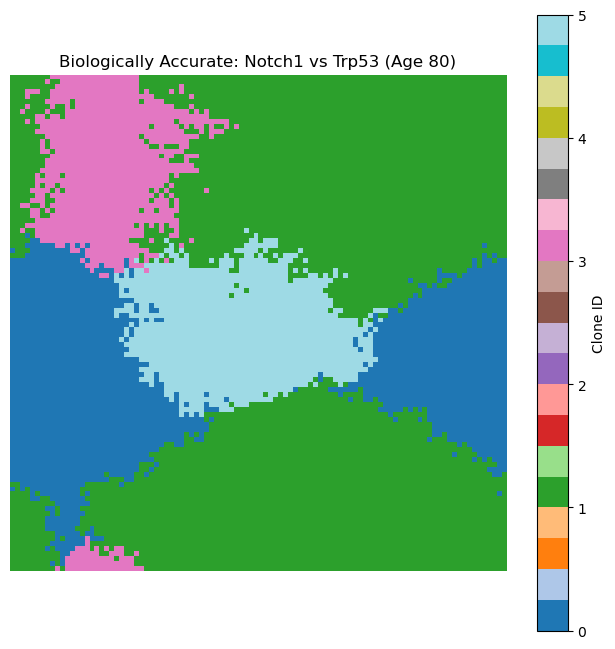

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from clone_competition_simulation import (
    Parameters, Gene, FixedValue, MutationGenerator, EpistaticEffect,
    PopulationParameters, TimeParameters, FitnessParameters
)

# --- 1. SETTINGS FROM YOUR ABC RESULTS ---
S_NOTCH1 = 0.389  
S_TP53 = 1.400    
MUT_RATE = 1e-5     # Slightly elevated so we see mutations in a small grid
MAX_AGE = 80      
GRID_SIZE = 10000   # 100x100 perfect square for WF2D algorithm

# --- 2. DEFINE COMPETITION MODEL ---
mut_gen = MutationGenerator(
    genes=[
        Gene(name='Notch1', mutation_distribution=FixedValue(1.0 + S_NOTCH1), synonymous_proportion=0), 
        Gene(name='Trp53', mutation_distribution=FixedValue(1.0 + S_TP53), synonymous_proportion=0)
    ],                 
    # BIOLOGICAL UPDATE: Antagonistic Epistasis
    # If Trp53 mutates in a cell that already has Notch1, the fitness stays at Notch1's level (1.389)
    # This prevents TP53 from exploiting its massive 2.4 fitness advantage!
    epistatics=[
        EpistaticEffect(
            name='Notch1_Trp53_Trap', 
            gene_names=['Notch1', 'Trp53'], 
            fitness_distribution=FixedValue(1.0 + S_NOTCH1)
        )
    ],
    multi_gene_array=True,
    combine_mutations='replace',   
)

# Setup parameters matching the repo's structure exactly
np.random.seed(42)
p = Parameters(
    algorithm='WF2D',
    times=TimeParameters(max_time=MAX_AGE, division_rate=1),
    # cell_in_own_neighbourhood is specific to spatial algorithms
    population=PopulationParameters(initial_cells=GRID_SIZE, cell_in_own_neighbourhood=True),
    fitness=FitnessParameters(
        mutation_rates=MUT_RATE, 
        mutation_generator=mut_gen,     
    )
)

# --- 3. EXECUTION ---
print("🚀 Running Biological Antagonism Model (NOTCH1 trapping TP53)...")
s = p.get_simulator()
s.run_sim()

# --- 4. ANALYZE CLONES ---
print("\n📊 Final Clone Info (Top 10 largest clones):")
df_clones = s.view_clone_info(include_raw_fitness=True)

if df_clones is not None and not df_clones.empty:
    print(f"Available columns: {df_clones.columns.tolist()}")
    
    # Try to find the right column name for size
    size_col = None
    for col in ['size', 'clone_size', 'cells', 'N', 'Count', 'count']:
        if col in df_clones.columns:
            size_col = col
            break
            
    if size_col:
        print(df_clones.sort_values(by=size_col, ascending=False).head(10).to_string())
    else:
        # If we can't find the size column, just print the top of the dataframe
        print(df_clones.head(10).to_string())
else:
    print("No mutations occurred or survived.")

# --- 5. VISUALIZE THE TISSUE ---
if hasattr(s, 'grid_array'):
    # The grid is stored as a 1D array of length 10000. 
    # We need to reshape it into a 100x100 2D matrix for the image.
    grid_1d = np.array(s.grid_array)
    grid_dim = int(np.sqrt(len(grid_1d)))
    grid_2d = grid_1d.reshape((grid_dim, grid_dim))
    
    plt.figure(figsize=(8, 8))
    # 'tab20' gives distinct colors to different clone IDs
    plt.imshow(grid_2d, cmap='tab20', interpolation='nearest') 
    plt.colorbar(label='Clone ID')
    plt.title("Biologically Accurate: Notch1 vs Trp53 (Age 80)")
    plt.axis('off') # Hide the axis ticks for a cleaner tissue look
    plt.show()
else:
    print("Could not find grid_array.")


🚀 Running Biological Antagonism Model (NOTCH1 trapping TP53)...

📊 Final Clone Info (Top 10 largest clones):
Available columns: ['clone id', 'label', 'fitness', 'generation born', 'parent clone id', 'last gene mutated', 'Initial clone fitness', 'Notch1', 'Trp53', 'Notch1_Trp53_Trap']
   clone id  label  fitness  generation born  parent clone id last gene mutated  Initial clone fitness  Notch1  Trp53  Notch1_Trp53_Trap
0         0      0    1.000                0               -1              None                    1.0     NaN    NaN                NaN
1         1      0    2.400                2                0             Trp53                    1.0     NaN    2.4                NaN
2         2      0    2.400               11                0             Trp53                    1.0     NaN    2.4                NaN
3         3      0    2.400               32                0             Trp53                    1.0     NaN    2.4                NaN
4         4      0    2.400   

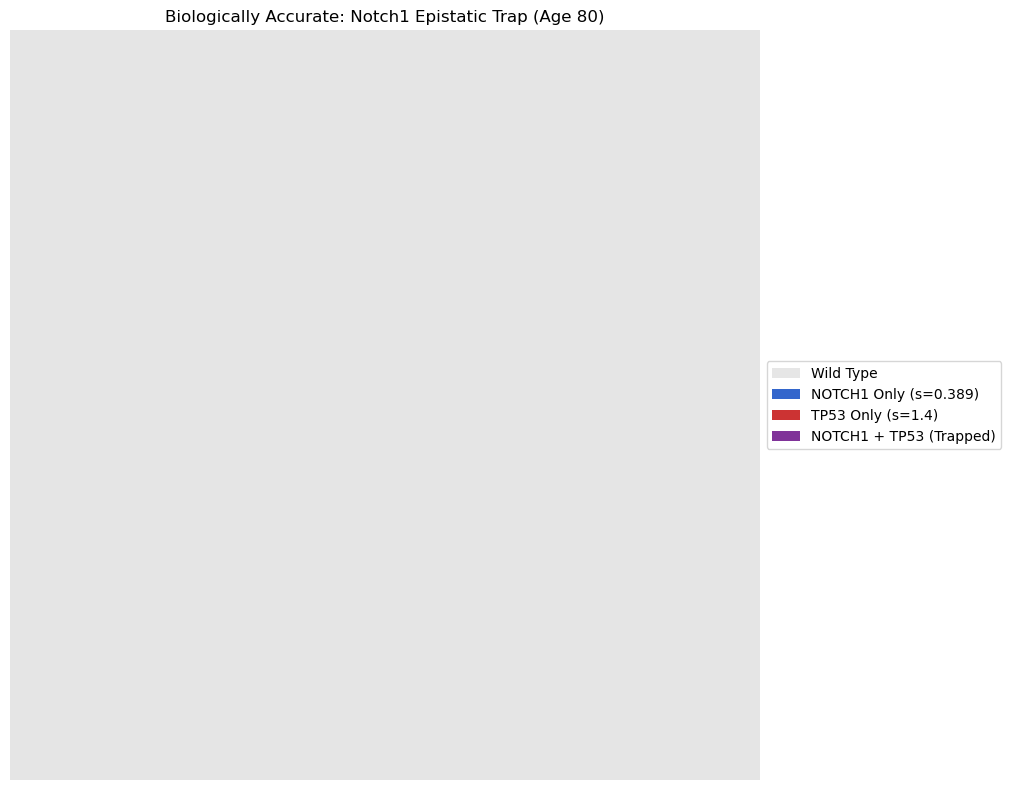

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from clone_competition_simulation import (
    Parameters, Gene, FixedValue, MutationGenerator, EpistaticEffect,
    PopulationParameters, TimeParameters, FitnessParameters
)

# --- 1. SETTINGS FROM YOUR ABC RESULTS ---
S_NOTCH1 = 0.389  
S_TP53 = 1.400    
MUT_RATE = 1e-5     # Slightly elevated so we see mutations in a small grid
MAX_AGE = 80      
GRID_SIZE = 10000   # 100x100 perfect square for WF2D algorithm

# --- 2. DEFINE COMPETITION MODEL ---
mut_gen = MutationGenerator(
    genes=[
        Gene(name='Notch1', mutation_distribution=FixedValue(1.0 + S_NOTCH1), synonymous_proportion=0), 
        Gene(name='Trp53', mutation_distribution=FixedValue(1.0 + S_TP53), synonymous_proportion=0)
    ],                 
    # BIOLOGICAL UPDATE: Antagonistic Epistasis
    # If Trp53 mutates in a cell that already has Notch1, the fitness stays at Notch1's level (1.389)
    # This prevents TP53 from exploiting its massive 2.4 fitness advantage!
    epistatics=[
        EpistaticEffect(
            name='Notch1_Trp53_Trap', 
            gene_names=['Notch1', 'Trp53'], 
            fitness_distribution=FixedValue(1.0 + S_NOTCH1)
        )
    ],
    multi_gene_array=True,
    combine_mutations='replace',   
)

# Setup parameters matching the repo's structure exactly
np.random.seed(42)
p = Parameters(
    algorithm='WF2D',
    times=TimeParameters(max_time=MAX_AGE, division_rate=1),
    # cell_in_own_neighbourhood is specific to spatial algorithms
    population=PopulationParameters(initial_cells=GRID_SIZE, cell_in_own_neighbourhood=True),
    fitness=FitnessParameters(
        mutation_rates=MUT_RATE, 
        mutation_generator=mut_gen,     
    )
)

# --- 3. EXECUTION ---
print("🚀 Running Biological Antagonism Model (NOTCH1 trapping TP53)...")
s = p.get_simulator()
s.run_sim()

# --- 4. ANALYZE CLONES ---
print("\n📊 Final Clone Info (Top 10 largest clones):")
df_clones = s.view_clone_info(include_raw_fitness=True)

if df_clones is not None and not df_clones.empty:
    print(f"Available columns: {df_clones.columns.tolist()}")
    
    # Try to find the right column name for size
    size_col = None
    for col in ['size', 'clone_size', 'cells', 'N', 'Count', 'count']:
        if col in df_clones.columns:
            size_col = col
            break
            
    if size_col:
        print(df_clones.sort_values(by=size_col, ascending=False).head(10).to_string())
    else:
        # If we can't find the size column, just print the top of the dataframe
        print(df_clones.head(10).to_string())
else:
    print("No mutations occurred or survived.")
    
from matplotlib.patches import Patch

# --- 5. VISUALIZE BY GENOTYPE (BIOLOGICAL COLORING) ---
if hasattr(s, 'grid_array'):
    # Get the clone data and the grid
    df_clones = s.view_clone_info()
    grid_1d = np.array(s.grid_array)
    grid_dim = int(np.sqrt(len(grid_1d)))
    grid_2d = grid_1d.reshape((grid_dim, grid_dim))
    
    # Create an empty RGB image canvas (white/grey background)
    rgb_grid = np.full((grid_dim, grid_dim, 3), 0.9) 
    
    # Define our biological color palette (R, G, B)
    COLOR_WT = [0.9, 0.9, 0.9]       # Light Grey
    COLOR_NOTCH1 = [0.2, 0.4, 0.8]   # Blue
    COLOR_TP53 = [0.8, 0.2, 0.2]     # Red
    COLOR_TRAP = [0.5, 0.2, 0.6]     # Purple
    
    # Map the grid: Color each cell based on its clone's genotype
    for _, row in df_clones.iterrows():
        c_id = int(row['clone id'])
        
        # Check which mutations this specific clone has
        has_notch1 = pd.notna(row.get('Notch1'))
        has_tp53 = pd.notna(row.get('Trp53'))
        
        if has_notch1 and has_tp53:
            color = COLOR_TRAP
        elif has_tp53:
            color = COLOR_TP53
        elif has_notch1:
            color = COLOR_NOTCH1
        else:
            color = COLOR_WT
            
        # Apply the color to all pixels on the grid that belong to this clone
        mask = (grid_2d == c_id)
        rgb_grid[mask] = color
        
    # Plot the colored RGB grid
    plt.figure(figsize=(10, 8))
    plt.imshow(rgb_grid, interpolation='nearest') 
    
    # Create a custom legend
    legend_elements = [
        Patch(facecolor=COLOR_WT, label='Wild Type'),
        Patch(facecolor=COLOR_NOTCH1, label=f'NOTCH1 Only (s={S_NOTCH1})'),
        Patch(facecolor=COLOR_TP53, label=f'TP53 Only (s={S_TP53})'),
        Patch(facecolor=COLOR_TRAP, label='NOTCH1 + TP53 (Trapped)')
    ]
    plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
    
    plt.title("Biologically Accurate: Notch1 Epistatic Trap (Age 80)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

else:
    print("Could not find grid_array.")